In [9]:
import pandas as pd
import numpy as np
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator


#------------------configuración y cargade datos ------------------

raw_df_clean = pd.read_parquet(r"C:\Users\pablo.esparcia\Documents\OptionMetrics\Descriptivos\opt_df.parquet")
opt_df = raw_df_clean

In [10]:
fp_df = pd.read_parquet(r"C:\Users\pablo.esparcia\Documents\OptionMetrics\Descriptivos\fp.parquet")
zc_df = pd.read_parquet(r"C:\Users\pablo.esparcia\Documents\OptionMetrics\Descriptivos\zc.parquet")


Creo algunas columnas útliles y eliminamos datos no válidos (-99.99):

In [11]:
opt_df["Date"] = pd.to_datetime(opt_df["Date"], format="%Y-%m-%d")
opt_df["Expiration"] = pd.to_datetime(opt_df["Expiration"], format="%Y-%m-%d")
opt_df["Days"] = ((opt_df["Expiration"] - opt_df["Date"]).dt.days - opt_df["AMSettlement"])
opt_df["Strike"] = opt_df["Strike"]/1000
opt_df = opt_df[opt_df["ImpliedVolatility"] != -99.99]

opt_df["MidPrice"] = (opt_df["Bid"] + opt_df["Ask"]) / 2
opt_df["horquilla"] = (opt_df["Ask"] - opt_df["Bid"])/ opt_df["MidPrice"]


Asignamos Forward Price para calcular el moneyness:

In [12]:

opt_bloque = []

for fecha, opt_fecha in opt_df.groupby("Date"):
    #print(f"Procesando fecha {fecha.date()} con {len(opt_fecha)} opciones...")
    fp_fecha = fp_df[fp_df["Date"] == fecha]
    fp_fecha = fp_fecha.sort_values("Days")  # Aseguramos que esté ordenado por tiempo a vencimiento
    if fp_fecha.empty:
        print(f"No hay datos de forward price para la fecha {fecha}")
        continue
    curva_fecha = zc_df[(zc_df["Date"] == fecha) & (zc_df["Currency"] == 333)]
    if curva_fecha.empty:
        print(f"No hay zero curve (Currency=333) para la fecha {fecha}")
        continue
    opt_fecha["forward_index"] = np.interp(opt_fecha["Days"], fp_fecha["Days"], fp_fecha["ForwardPrice"])
    opt_fecha["Rate"] = interpolate_rates_surface(zc_df, opt_fecha, fecha, 333, 365)

    opt_bloque.append(opt_fecha)

opt_df_2 = pd.concat(opt_bloque, ignore_index=True)

opt_df_2["Moneyness"] = opt_df_2["Strike"] / opt_df_2["forward_index"]
opt_df_2["log_moneyness"] = np.log(opt_df_2["Moneyness"])
opt_df_2["flag_otm"] = (
    ((opt_df_2["CallPut"] == "P") & (opt_df_2["Moneyness"] <= 1)) |
    ((opt_df_2["CallPut"] == "C") & (opt_df_2["Moneyness"] >= 1))
)


No hay zero curve (Currency=333) para la fecha 2003-10-13 00:00:00
No hay zero curve (Currency=333) para la fecha 2003-11-11 00:00:00
No hay zero curve (Currency=333) para la fecha 2004-10-11 00:00:00
No hay zero curve (Currency=333) para la fecha 2004-11-11 00:00:00
No hay zero curve (Currency=333) para la fecha 2005-10-10 00:00:00
No hay zero curve (Currency=333) para la fecha 2005-11-11 00:00:00
No hay zero curve (Currency=333) para la fecha 2006-10-09 00:00:00
No hay zero curve (Currency=333) para la fecha 2007-10-08 00:00:00
No hay zero curve (Currency=333) para la fecha 2007-11-12 00:00:00


In [13]:
opt_df_2.head(10)

,SecurityID,OptionID,Date,Expiration,Strike,CallPut,Bid,Ask,Volume,OpenInterest,...,Vega,Theta,Days,MidPrice,horquilla,forward_index,Rate,Moneyness,log_moneyness,flag_otm
0,108105,20884382,2003-01-02,2003-01-18,810.0,C,98.4,100.4,2,1092,...,11.69511,-41.23674,15,99.40,0.020121,908.8181,0.013753,0.891267,-0.115111,False
1,108105,20876996,2003-01-02,2003-01-18,825.0,C,83.9,85.9,574,5527,...,18.02797,-65.00201,15,84.90,0.023557,908.8181,0.013753,0.907772,-0.096762,False
2,108105,20876997,2003-01-02,2003-01-18,850.0,C,60.3,62.3,352,3634,...,32.16503,-110.58680,15,61.30,0.032626,908.8181,0.013753,0.935281,-0.066909,False
3,108105,21377919,2003-01-02,2003-01-18,860.0,C,51.3,53.3,1,14,...,39.73530,-133.50640,15,52.30,0.038241,908.8181,0.013753,0.946284,-0.055213,False
4,108105,21349900,2003-01-02,2003-01-18,870.0,C,42.7,44.7,0,165,...,48.04552,-157.64410,15,43.70,0.045767,908.8181,0.013753,0.957287,-0.043652,False
5,108105,20876998,2003-01-02,2003-01-18,875.0,C,38.5,40.0,5713,13386,...,51.49298,-162.46500,15,39.25,0.038217,908.8181,0.013753,0.962789,-0.037921,False
6,108105,21409283,2003-01-02,2003-01-18,880.0,C,34.4,36.4,327,1266,...,56.02784,-176.50650,15,35.40,0.056497,908.8181,0.013753,0.968291,-0.032223,False
7,108105,21391220,2003-01-02,2003-01-18,885.0,C,30.5,32.5,69,9,...,59.91505,-185.34150,15,31.50,0.063492,908.8181,0.013753,0.973792,-0.026557,False
8,108105,21355838,2003-01-02,2003-01-18,890.0,C,26.8,28.8,11,13,...,63.50474,-193.21140,15,27.80,0.071942,908.8181,0.013753,0.979294,-0.020924,False
9,108105,21411661,2003-01-02,2003-01-18,895.0,C,23.2,25.2,30,10,...,66.53670,-197.82850,15,24.20,0.082645,908.8181,0.013753,0.984796,-0.015321,False


## Descriptivos

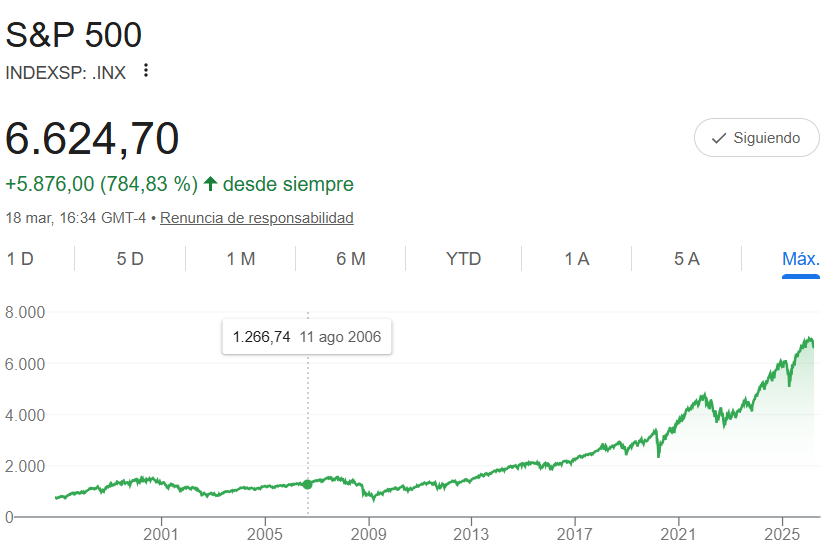

## Percentiles de Strike y Moneyness:

In [14]:
desc_strike = opt_df_2['Strike'].astype(float).describe(percentiles=[.01,.05,.10,.25,.50,.75,.90,.95,.99])
desc_moneyness   = opt_df_2['Moneyness'].astype(float).describe(percentiles=[.01,.05,.10,.25,.50,.75,.90,.95,.99])
desc_logm   = opt_df_2['log_moneyness'].astype(float).describe(percentiles=[.01,.05,.10,.25,.50,.75,.90,.95,.99])

pd.concat([desc_strike, desc_moneyness, desc_logm], axis=1).style.format("{:,.4f}")

#El valor del SP500 desde el 2003 al 2024 es: 900-6000 aprox.

,Strike,Moneyness,log_moneyness
count,"34,244,379.0000","34,244,379.0000","34,244,379.0000"
mean,"2,884.0926",0.9030,-0.1424
std,"1,233.6874",0.2215,0.3204
min,50.0000,0.0210,-3.8654
1%,550.0000,0.2547,-1.3677
5%,"1,005.0000",0.4915,-0.7104
10%,"1,300.0000",0.6263,-0.4679
25%,"1,945.0000",0.8006,-0.2224
50%,"2,800.0000",0.9318,-0.0706
75%,"3,850.0000",1.0232,0.0229


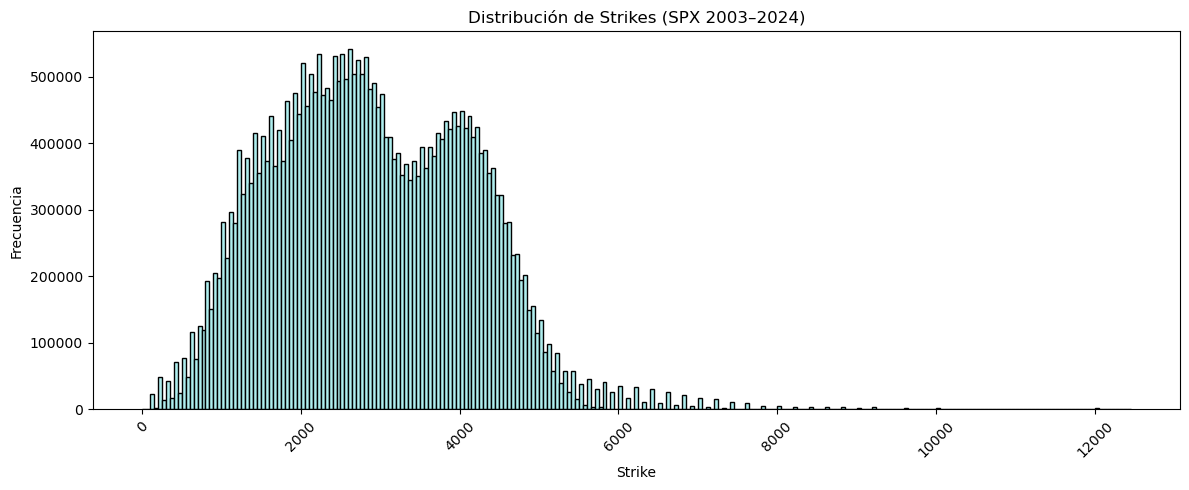

In [15]:

opt_df_2['Strike'].plot.hist(bins=np.arange(0, 12500, 50), figsize=(12, 5), edgecolor='black', color='paleturquoise')

plt.xlabel('Strike')
plt.ylabel('Frecuencia')
plt.title('Distribución de Strikes (SPX 2003–2024)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

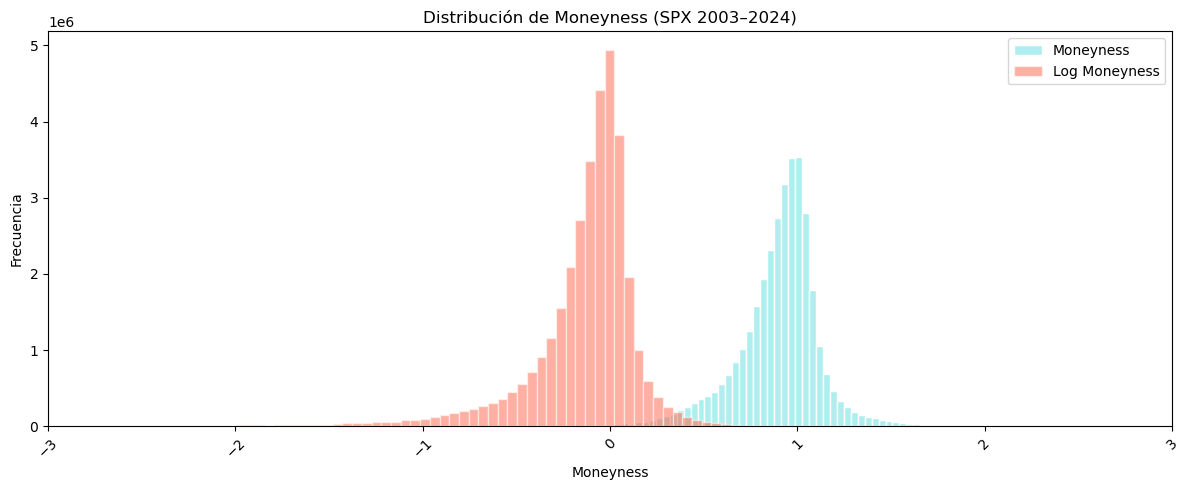

In [16]:
opt_df_2['Moneyness'].plot.hist(bins=100, figsize=(12, 5), edgecolor='white', color='paleturquoise')
opt_df_2['log_moneyness'].plot.hist(bins=100, figsize=(12, 5), edgecolor='white', color='tomato',alpha =0.5, label = 'Log Moneyness')
plt.xlim(-3,3)
plt.xlabel('Moneyness')
plt.ylabel('Frecuencia')
plt.title('Distribución de Moneyness (SPX 2003–2024)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Número en bruto de opciones call y put:

In [17]:
n_calls = (opt_df_2["CallPut"] == "C").sum()
n_puts  = (opt_df_2["CallPut"] == "P").sum()

print(f"Número de calls: {n_calls:,}")
print(f"Número de puts:  {n_puts:,}")
print(f"Relación P/C:    {100*(1-n_calls/n_puts):.4f}%")

Número de calls: 16,698,394
Número de puts:  17,545,985
Relación P/C:    4.8307%


Número de opciones Call y Put con strikes únicos:

In [18]:
n_calls = opt_df_2[opt_df_2["CallPut"] == "C"]["Strike"].unique().sum()
n_puts  = opt_df_2[opt_df_2["CallPut"] == "P"]["Strike"].unique().sum()

print(f"Número de calls: {n_calls:,}")
print(f"Número de puts:  {n_puts:,}")
print(f"Relación P/C:    {100*(1-n_calls/n_puts):.4f}%")

Número de calls: 3,460,217.0
Número de puts:  3,392,117.0
Relación P/C:    -2.0076%


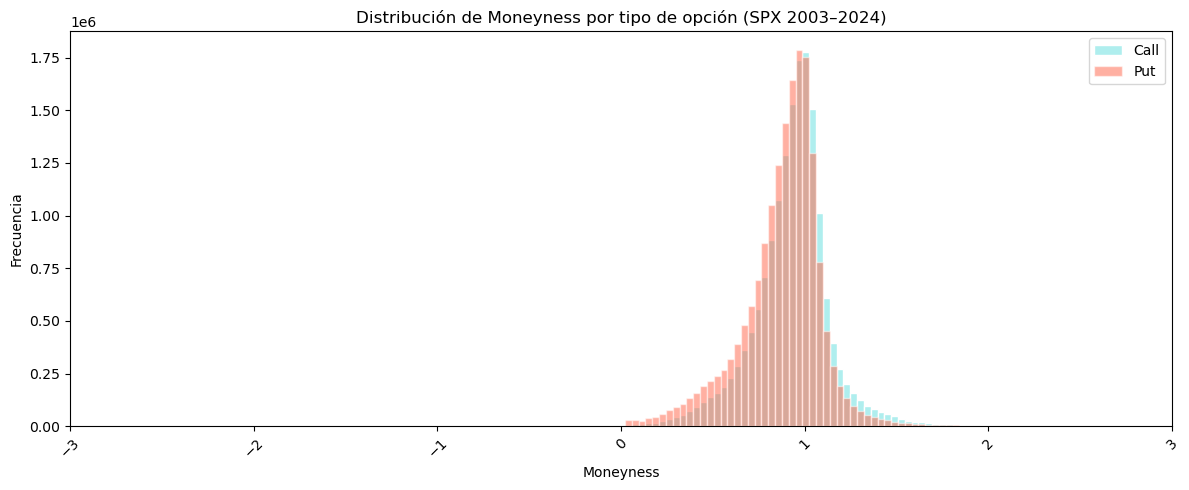

In [19]:
cmask = opt_df_2["CallPut"] == "C"

opt_df_2[cmask]['Moneyness'].plot.hist(bins=100, figsize=(12, 5), edgecolor='white', color='paleturquoise', label = 'Call')
opt_df_2[~cmask]['Moneyness'].plot.hist(bins=100, figsize=(12, 5), edgecolor='white', color='tomato',alpha =0.5, label = 'Put')
plt.xlim(-3,3)
plt.xlabel('Moneyness')
plt.ylabel('Frecuencia')
plt.title('Distribución de Moneyness por tipo de opción (SPX 2003–2024)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Hay ligeramente más número de puts (4.8307%) que de calls, con calls con strikes más altos y puts con mayor densidad en strikes más bajos.
Con strikes repetidos eliminados, hay más cantidad de call que de puts, por lo que las puts tienen más contratos a distintos vencimientos que las calls.

¿Podría ser interesante homogeneizar y tener el mismo número de call y puts en los mismos rangos del moneyness?(creo que solo en número, ver tras quitar extremos)

### Previsualización de precios:

In [20]:
desc_bid = opt_df_2['Bid'].astype(float).describe(percentiles=[.01,.05,.10,.25,.50,.75,.90,.95,.99])
desc_ask   = opt_df_2['Ask'].astype(float).describe(percentiles=[.01,.05,.10,.25,.50,.75,.90,.95,.99])
desc_mid   = opt_df_2['MidPrice'].astype(float).describe(percentiles=[.01,.05,.10,.25,.50,.75,.90,.95,.99])
desc_horquilla  = opt_df_2['horquilla'].astype(float).describe(percentiles=[.01,.05,.10,.25,.50,.75,.90,.95,.99])

pd.concat([desc_bid, desc_ask, desc_mid, desc_horquilla], axis=1).style.format("{:,.4f}")

,Bid,Ask,MidPrice,horquilla
count,"34,244,379.0000","34,244,379.0000","34,244,379.0000","34,244,379.0000"
mean,248.2221,251.9822,250.1021,0.2152
std,439.0004,443.6627,441.3095,0.5042
min,0.0000,0.0500,0.0250,-0.2778
1%,0.0000,0.0500,0.0250,0.0022
5%,0.0000,0.1000,0.0750,0.0044
10%,0.2000,0.4000,0.3000,0.0060
25%,4.5000,5.0000,4.7500,0.0108
50%,65.6000,67.4000,66.5000,0.0244
75%,297.5000,303.2000,300.3500,0.0873


### Filtros básicos del BID-ASK

Quito: Bid<0 (redundante) ; Bid>ASK


In [21]:
bamask = (opt_df_2["Bid"]>=0) & (opt_df_2["Ask"] > opt_df_2["Bid"])
filt_opt_df = opt_df_2[bamask].copy()

In [22]:
desc_bid = filt_opt_df['Bid'].astype(float).describe(percentiles=[.01,.05,.10,.25,.50,.75,.90,.95,.99])
desc_ask   = filt_opt_df['Ask'].astype(float).describe(percentiles=[.01,.05,.10,.25,.50,.75,.90,.95,.99])
desc_mid   = filt_opt_df['MidPrice'].astype(float).describe(percentiles=[.01,.05,.10,.25,.50,.75,.90,.95,.99])
desc_horquilla  = filt_opt_df['horquilla'].astype(float).describe(percentiles=[.01,.05,.10,.25,.50,.75,.90,.95,.99])

pd.concat([desc_bid, desc_ask, desc_mid, desc_horquilla], axis=1).style.format("{:,.4f}")

,Bid,Ask,MidPrice,horquilla
count,"34,244,334.0000","34,244,334.0000","34,244,334.0000","34,244,334.0000"
mean,248.2219,251.9820,250.1019,0.2152
std,439.0004,443.6627,441.3094,0.5042
min,0.0000,0.0500,0.0250,0.0002
1%,0.0000,0.0500,0.0250,0.0022
5%,0.0000,0.1000,0.0750,0.0044
10%,0.2000,0.4000,0.3000,0.0060
25%,4.5000,5.0000,4.7500,0.0108
50%,65.6000,67.4000,66.5000,0.0244
75%,297.5000,303.2000,300.3500,0.0873


Se eliminan bajo estos filtros 45,000 puntos lo que no afecta en gran medida a la distribución de strikes.

Distribución de los srikes eliminados:

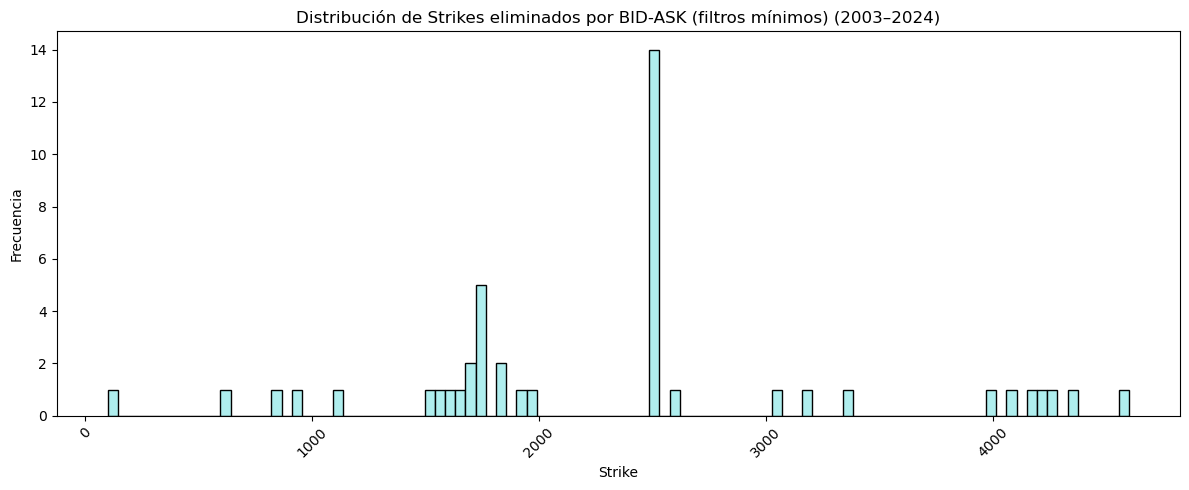

In [23]:
opt_df_2[~bamask]["Strike"].plot.hist(bins=100, figsize=(12, 5), edgecolor='black', color='paleturquoise')

plt.xlabel('Strike')
plt.ylabel('Frecuencia')
plt.title('Distribución de Strikes eliminados por BID-ASK (filtros mínimos) (2003–2024)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Vencimientos:

In [24]:
(filt_opt_df['Days']/1).astype(float).describe(percentiles=[.01,.05,.10,.25,.50,.75,.90,.95,.99]).to_frame().style.format("{:,.4f}")

,Days
count,"34,244,334.0000"
mean,126.2591
std,194.8058
min,1.0000
1%,1.0000
5%,5.0000
10%,9.0000
25%,23.0000
50%,58.0000
75%,137.0000


### Strikes agrupando por vencimiento

In [25]:

labels=['D1','D2','D3','D4','D5','D6','D7','D8','D9','D10']
filt_opt_df['Days_bin'] = pd.qcut(filt_opt_df['Days'], q=10, labels = labels)


filt_opt_df.groupby('Days_bin',observed=True)['Strike'].describe(
    percentiles=[.05, .25, .50, .75, .95]
).style.format("{:,.4f}")

,count,mean,std,min,5%,25%,50%,75%,95%,max
Days_bin,,,,,,,,,,
D1,"3,468,928.0000","3,100.0278","1,103.3816",200.0000,"1,290.0000","2,245.0000","3,060.0000","4,015.0000","4,745.0000","8,300.0000"
D2,"3,433,938.0000","3,055.8788","1,108.0257",150.0000,"1,250.0000","2,205.0000","3,000.0000","3,985.0000","4,710.0000","8,300.0000"
D3,"3,545,300.0000","3,058.6762","1,095.0927",100.0000,"1,285.0000","2,240.0000","2,970.0000","3,975.0000","4,720.0000","8,300.0000"
D4,"3,298,498.0000","2,862.1858","1,120.1005",100.0000,"1,150.0000","2,020.0000","2,750.0000","3,760.0000","4,700.0000","8,300.0000"
D5,"3,519,670.0000","2,761.5928","1,135.5407",50.0000,"1,085.0000","1,900.0000","2,625.0000","3,635.0000","4,675.0000","8,300.0000"
D6,"3,310,016.0000","2,734.2005","1,166.6486",50.0000,"1,025.0000","1,840.0000","2,600.0000","3,625.0000","4,700.0000","8,300.0000"
D7,"3,495,369.0000","2,885.2796","1,191.2255",50.0000,"1,050.0000","1,980.0000","2,820.0000","3,810.0000","4,790.0000","8,300.0000"
D8,"3,363,059.0000","3,114.1199","1,218.3480",50.0000,"1,050.0000","2,230.0000","3,190.0000","4,025.0000","4,900.0000","8,200.0000"
D9,"3,400,724.0000","2,678.9537","1,384.5487",50.0000,800.0000,"1,525.0000","2,525.0000","3,685.0000","5,025.0000","9,200.0000"


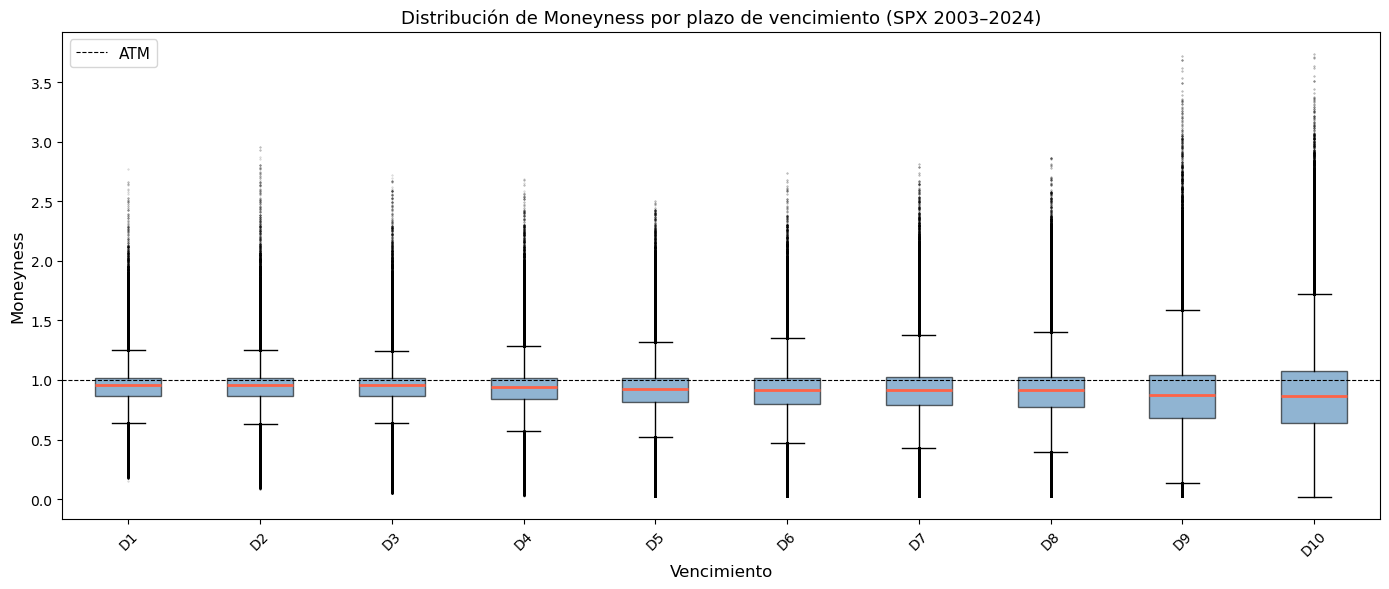

In [26]:
fig, ax = plt.subplots(figsize=(14, 6))

groups = [filt_opt_df[filt_opt_df['Days_bin'] == label]['Moneyness'].dropna()
          for label in labels]

ax.boxplot(groups, tick_labels=labels, patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6),
           medianprops=dict(color='tomato', linewidth=2),
           flierprops=dict(marker='.', markersize=1, alpha=0.2))

ax.set_xlabel('Vencimiento', fontsize=12)
ax.set_ylabel('Moneyness', fontsize=12)
ax.set_title('Distribución de Moneyness por plazo de vencimiento (SPX 2003–2024)', fontsize=13)
ax.axhline(1, color='black', linestyle='--', linewidth=0.8, label='ATM')
ax.legend(fontsize=11)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

En lugar de cortes en conjuntos equivalentes, veamos los strikes en fechas específicas:

In [27]:
bins   = [0, 7, 14, 30, 45, 60, 90, 120, 180, 270, 365, np.inf]
labels = ['<1W', '1-2W', '2W-1M', '1-1.5M', '1.5-2M', '2-3M', '3-4M', '4-6M', '6-9M', '9-12M', '>12M']

filt_opt_df['Days_bin'] = pd.cut(filt_opt_df['Days'], bins=bins, labels=labels)

filt_opt_df.groupby('Days_bin',observed = True)['Strike'].describe(percentiles=[.01, .05, .25, .50, .75, .95, .99]
).style.format("{:,.2f}")

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Days_bin,,,,,,,,,,,,
<1W,"2,597,740.00","3,127.30","1,090.74",250.00,925.00,"1,320.00","2,290.00","3,095.00","4,030.00","4,750.00","5,325.00","8,300.00"
1-2W,"2,725,073.00","3,088.10","1,101.44",200.00,840.00,"1,280.00","2,245.00","3,040.00","4,010.00","4,725.00","5,300.00","8,300.00"
2W-1M,"5,875,678.00","3,014.32","1,111.61",100.00,800.00,"1,230.00","2,175.00","2,925.00","3,950.00","4,710.00","5,300.00","8,300.00"
1-1.5M,"3,661,493.00","2,837.65","1,124.63",50.00,700.00,"1,130.00","1,990.00","2,720.00","3,725.00","4,690.00","5,300.00","8,300.00"
1.5-2M,"2,767,551.00","2,728.38","1,130.30",50.00,665.00,"1,070.00","1,875.00","2,590.00","3,575.00","4,655.00","5,300.00","8,300.00"
2-3M,"3,889,515.00","2,774.22","1,177.57",50.00,600.00,"1,030.00","1,865.00","2,650.00","3,690.00","4,725.00","5,390.00","8,300.00"
3-4M,"3,016,916.00","2,918.40","1,194.03",50.00,550.00,"1,050.00","2,025.00","2,870.00","3,835.00","4,805.00","5,550.00","8,300.00"
4-6M,"3,342,519.00","3,109.47","1,224.53",50.00,550.00,"1,050.00","2,220.00","3,195.00","4,025.00","4,900.00","5,800.00","8,200.00"
6-9M,"1,845,909.00","2,628.80","1,390.07",50.00,350.00,750.00,"1,475.00","2,450.00","3,600.00","5,050.00","6,300.00","8,300.00"


Y moneyness:

In [28]:
bins   = [0, 7, 14, 30, 45, 60, 90, 120, 180, 270, 365, np.inf]
labels = ['<1W', '1-2W', '2W-1M', '1-1.5M', '1.5-2M', '2-3M', '3-4M', '4-6M', '6-9M', '9-12M', '>12M']

filt_opt_df['Days_bin'] = pd.cut(filt_opt_df['Days'], bins=bins, labels=labels)

filt_opt_df.groupby('Days_bin',observed = True)['Moneyness'].describe(percentiles=[.01, .05, .25, .50, .75, .95, .99]
).style.format("{:,.2f}")

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Days_bin,,,,,,,,,,,,
<1W,"2,597,740.00",0.94,0.15,0.21,0.46,0.67,0.87,0.96,1.02,1.14,1.35,2.64
1-2W,"2,725,073.00",0.93,0.17,0.12,0.36,0.62,0.87,0.96,1.02,1.14,1.35,2.96
2W-1M,"5,875,678.00",0.92,0.17,0.04,0.34,0.60,0.86,0.95,1.02,1.14,1.34,2.93
1-1.5M,"3,661,493.00",0.91,0.18,0.02,0.33,0.59,0.83,0.94,1.02,1.15,1.35,2.69
1.5-2M,"2,767,551.00",0.91,0.19,0.02,0.33,0.58,0.82,0.93,1.02,1.15,1.38,2.51
2-3M,"3,889,515.00",0.90,0.20,0.02,0.29,0.55,0.80,0.92,1.02,1.16,1.40,2.74
3-4M,"3,016,916.00",0.89,0.22,0.02,0.25,0.50,0.78,0.91,1.02,1.18,1.44,2.82
4-6M,"3,342,519.00",0.89,0.23,0.02,0.23,0.46,0.77,0.91,1.03,1.21,1.48,2.87
6-9M,"1,845,909.00",0.86,0.29,0.02,0.15,0.37,0.67,0.87,1.05,1.32,1.62,3.21


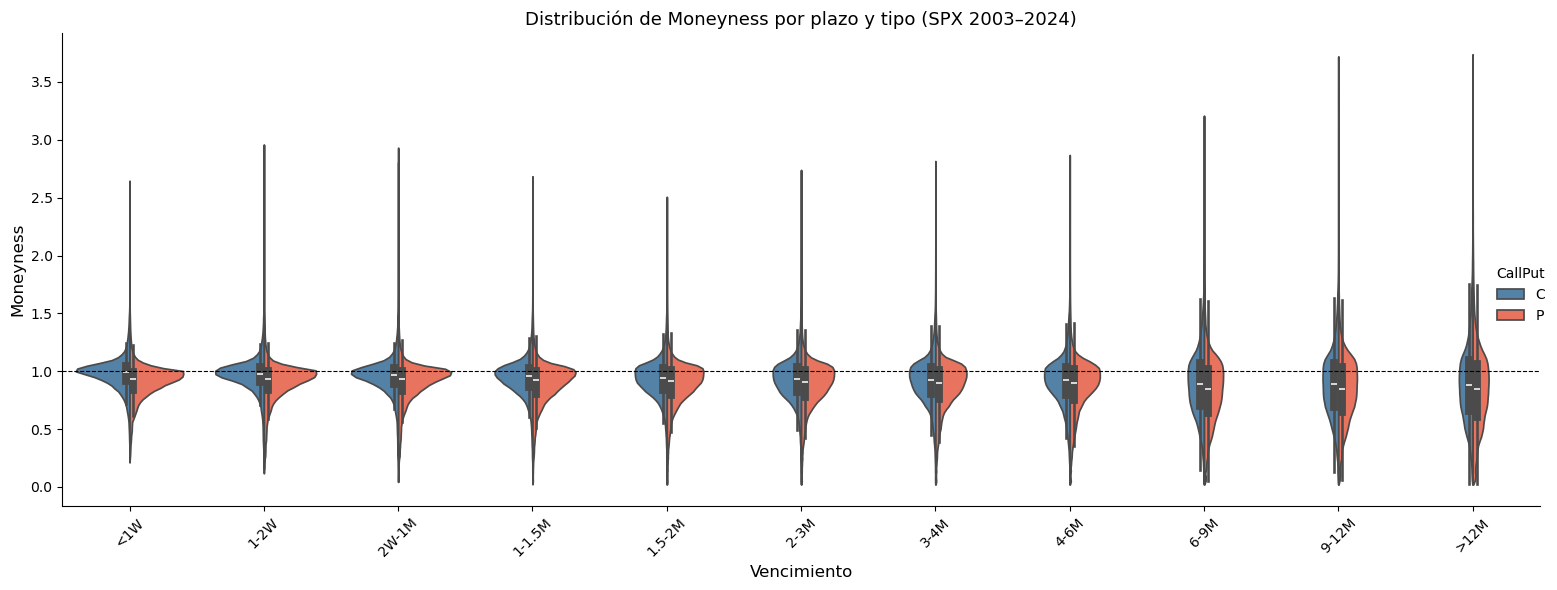

In [29]:
g = sns.catplot(
    data=filt_opt_df, x='Days_bin', y='Moneyness', hue='CallPut',
    kind='violin', bw_adjust=.5, cut=0, split=True,
    order=labels, palette={'C': 'steelblue', 'P': 'tomato'},
    height=6, aspect=2.5
)

g.ax.axhline(1, color='black', linestyle='--', linewidth=0.8, label='ATM')
g.ax.set_title('Distribución de Moneyness por plazo y tipo (SPX 2003–2024)', fontsize=13)
g.ax.tick_params(axis='x', rotation=45)
g.ax.set_xlabel('Vencimiento', fontsize=12)
g.ax.set_ylabel('Moneyness', fontsize=12)
plt.tight_layout()
plt.show()

Hagamos zoom al boxplot:

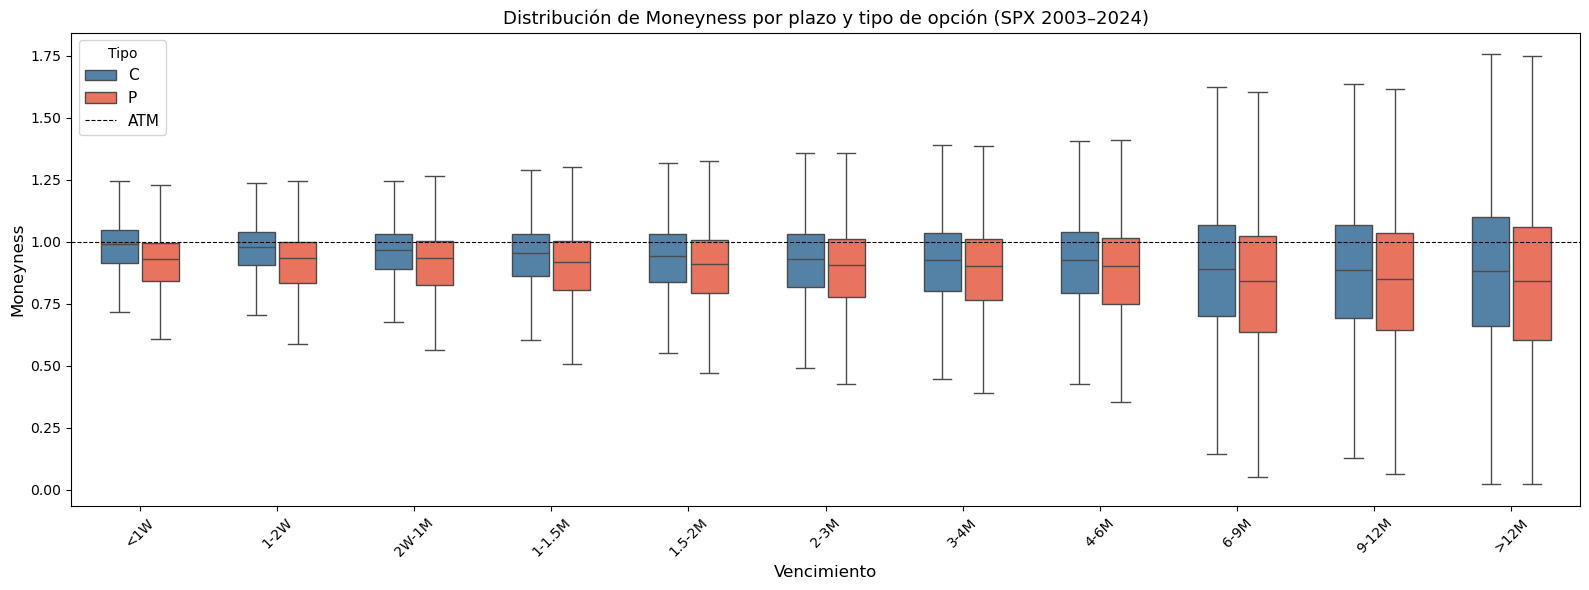

In [30]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(16, 6))

sns.boxplot(data=filt_opt_df, x='Days_bin', y='Moneyness',
            hue='CallPut', order=labels,
            palette={'C': 'steelblue', 'P': 'tomato'},
            showfliers=False,  # con 34M filas los fliers saturan
            width=0.6, gap=0.1,
            ax=ax)

ax.axhline(1, color='black', linestyle='--', linewidth=0.8, label='ATM')
ax.set_xlabel('Vencimiento', fontsize=12)
ax.set_ylabel('Moneyness', fontsize=12)
ax.set_title('Distribución de Moneyness por plazo y tipo de opción (SPX 2003–2024)', fontsize=13)
ax.legend(title='Tipo', fontsize=11)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

La distribución de moneyness transita de leptocúrtica a mesocúrtica al aumentar el vencimiento, reflejando que el mercado cotiza opciones en un rango de strikes progresivamente más amplio conforme crece el horizonte temporal.

La dispersión del moneyness crece de forma robusta y monótona con el vencimiento, resultado que se mantiene independientemente de si la agrupación se realiza por deciles o por de tiempo con mayor información económica (días) — descartando así un artefacto de discretización. Los outliers extremos se concentran de forma desproporcionada en los vencimientos más largos (>6M).

Asimismo, parece que la distribución es relativamente simétrica.

Controlando por vencimientos, se aprecia un RIC desplazado hacia abajo para puts. Manteniendo el valor máximo de Moneyness similar al de las calls, y el mínimo ligeramente más bajo, por lo que se observa una mediana de moneyness más baja en put que en calls para todos los vencimientos.

### ¿Cómo es la horquilla de liquidez?

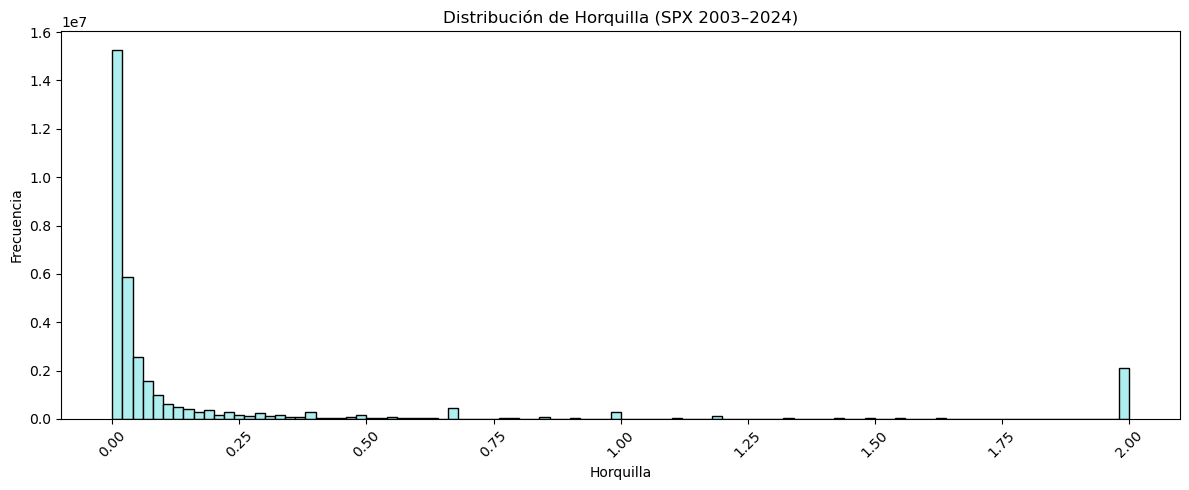

In [31]:

filt_opt_df['horquilla'].plot.hist(bins=100, figsize=(12, 5), edgecolor='black', color='paleturquoise')

plt.xlabel('Horquilla')
plt.ylabel('Frecuencia')
plt.title('Distribución de Horquilla (SPX 2003–2024)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Veamos la relación de las horquillas categorizadas con los strikes:

In [33]:

labels=['D1','D2','D3','D4','D5','D6','D7','D8','D9','D10']
filt_opt_df['horquilla_bins'] = pd.qcut(filt_opt_df['horquilla'], q=10, labels = labels)

filt_opt_df.groupby('horquilla_bins',observed=True)['Strike'].describe(
    percentiles=[0.1, .05, .25, .50, .75, .95, .99]
).style.format("{:,.4f}")

,count,mean,std,min,5%,10%,25%,50%,75%,95%,99%,max
horquilla_bins,,,,,,,,,,,,
D1,"3,424,439.0000","3,085.0616","1,206.7384",50.0000,925.0000,"1,300.0000","2,225.0000","3,275.0000","4,010.0000","4,675.0000","5,500.0000","12,000.0000"
D2,"3,424,465.0000","3,222.3331","1,120.1351",50.0000,"1,150.0000","1,575.0000","2,505.0000","3,385.0000","4,065.0000","4,715.0000","5,375.0000","12,000.0000"
D3,"3,424,515.0000","3,221.2844","1,083.3834",100.0000,"1,230.0000","1,655.0000","2,540.0000","3,315.0000","4,055.0000","4,725.0000","5,300.0000","12,000.0000"
D4,"3,424,367.0000","3,177.1728","1,070.0224",100.0000,"1,300.0000","1,675.0000","2,465.0000","3,225.0000","4,025.0000","4,725.0000","5,200.0000","12,000.0000"
D5,"3,424,671.0000","3,079.5371","1,078.7147",100.0000,"1,300.0000","1,635.0000","2,280.0000","3,010.0000","3,950.0000","4,745.0000","5,200.0000","12,000.0000"
D6,"3,424,147.0000","2,925.0847","1,090.3007",100.0000,"1,275.0000","1,575.0000","2,095.0000","2,775.0000","3,800.0000","4,745.0000","5,175.0000","12,000.0000"
D7,"3,433,071.0000","2,781.6534","1,087.4284",100.0000,"1,230.0000","1,500.0000","2,000.0000","2,575.0000","3,525.0000","4,730.0000","5,250.0000","12,000.0000"
D8,"3,415,794.0000","2,546.1773","1,124.3608",100.0000,"1,100.0000","1,300.0000","1,750.0000","2,290.0000","3,125.0000","4,770.0000","5,600.0000","12,000.0000"
D9,"3,676,387.0000","2,370.3735","1,331.6880",50.0000,810.0000,"1,025.0000","1,425.0000","2,020.0000","3,030.0000","4,975.0000","6,400.0000","12,000.0000"


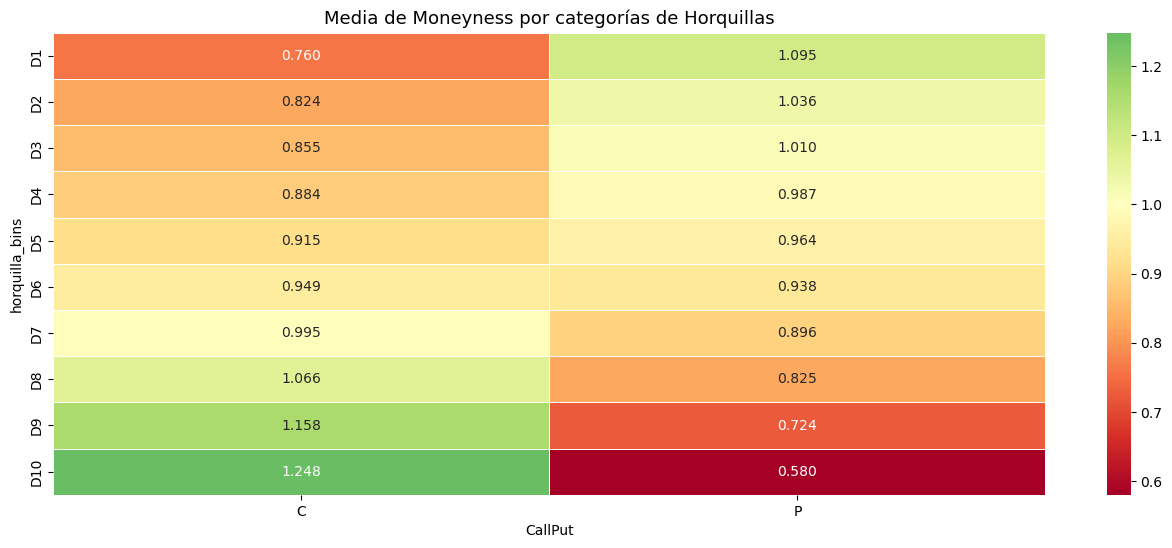

In [34]:
fig, ax = plt.subplots(figsize=(16, 6))

ax.set_title('Media de Moneyness por categorías de Horquillas', fontsize=13)

pivot = (filt_opt_df.groupby(['horquilla_bins', 'CallPut'], observed=True)['Moneyness']
         .mean().unstack())

sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', 
            center=1, ax=ax, linewidths=0.5)
plt.show()

Parece que hay un patrón monótono decreciente para el caso de calls entre la liquidez medida por la horquilla y moneyness, y creciente para puts.

### Porcentaje de dias de negociación de cada contrato por mes:

In [36]:

trading_days = (filt_opt_df.groupby(pd.Grouper(key='Date', freq='ME'))['Date'].nunique().rename('trading_days_mes'))

days_per_contract = (filt_opt_df.groupby(['OptionID', pd.Grouper(key='Date', freq='ME')])['Date'].nunique().rename('days_traded').reset_index())
    
days_per_contract = days_per_contract.merge(trading_days, on='Date')
days_per_contract['pct_days_traded'] = (days_per_contract['days_traded'] / days_per_contract['trading_days_mes'] * 100)

days_per_contract.head(10)

,OptionID,Date,days_traded,trading_days_mes,pct_days_traded
0,20390393,2003-01-31,21,21,100.000000
1,20390393,2003-02-28,19,19,100.000000
2,20390393,2003-03-31,21,21,100.000000
3,20390393,2003-04-30,21,21,100.000000
4,20390393,2003-05-31,21,21,100.000000
5,20390393,2003-06-30,13,21,61.904762
6,20390394,2003-01-31,21,21,100.000000
7,20390394,2003-02-28,19,19,100.000000
8,20390394,2003-03-31,21,21,100.000000
9,20390394,2003-04-30,21,21,100.000000


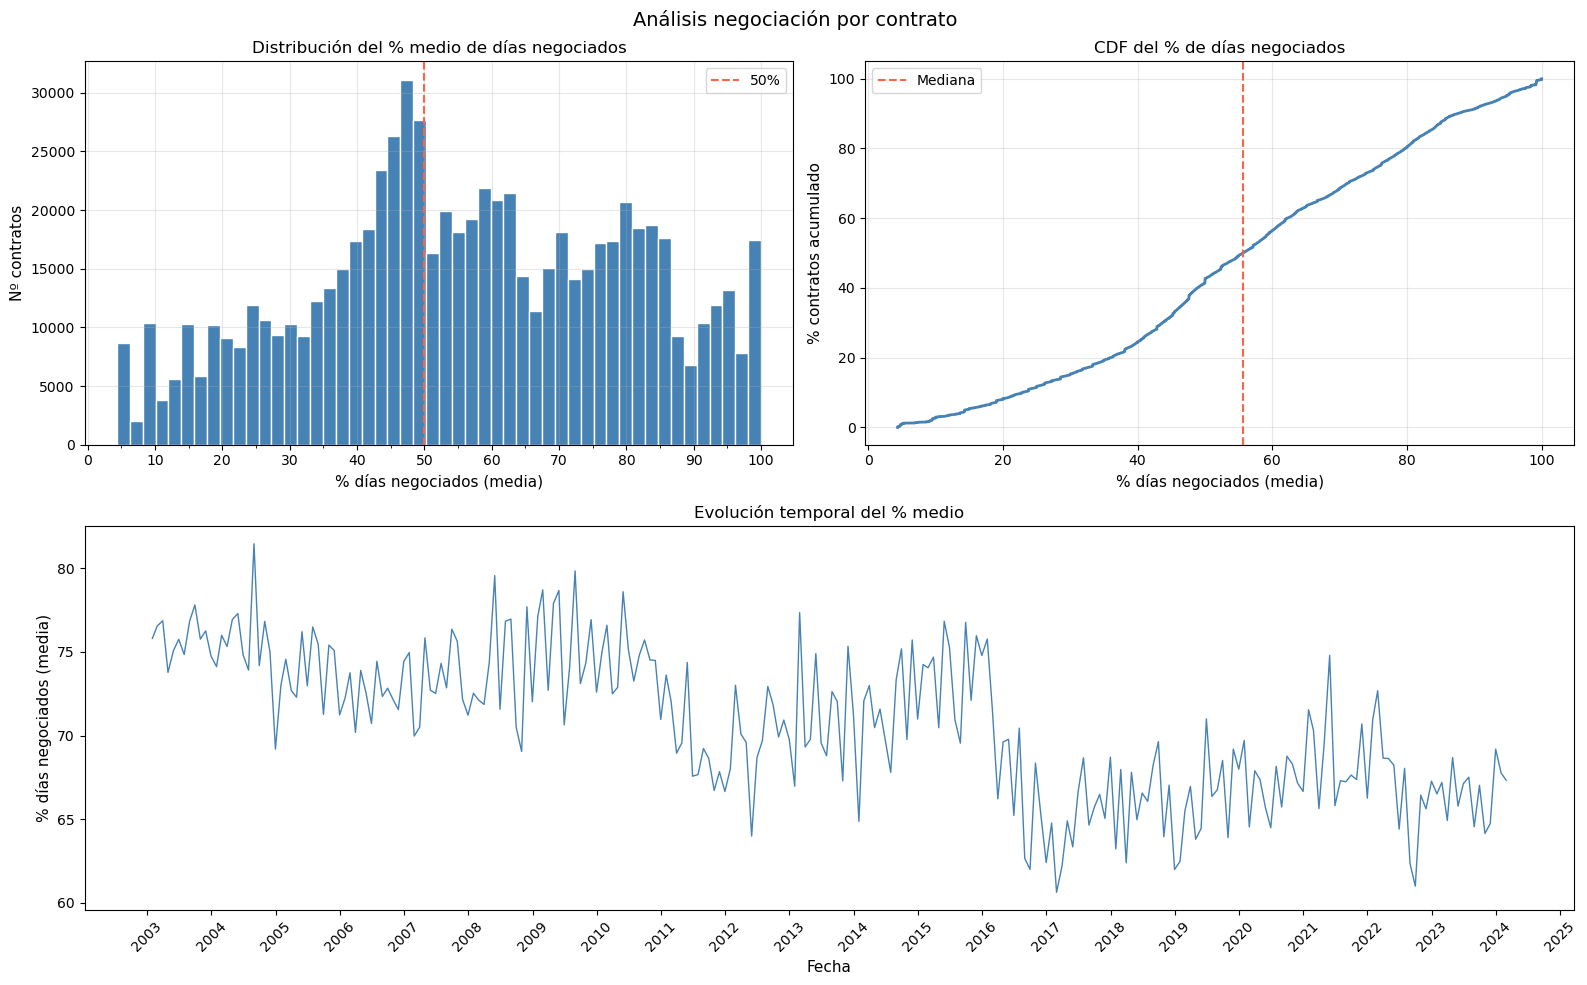

In [37]:

pct_summary = (days_per_contract.groupby('OptionID')['pct_days_traded']
               .mean()
               .reset_index()
               .rename(columns={'pct_days_traded': 'pct_medio'}))

fig = plt.figure(figsize=(16, 10))
fig.suptitle('Análisis negociación por contrato', fontsize=14)
gs  = GridSpec(2, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])  

# 1. Histograma
ax1.hist(pct_summary['pct_medio'], bins=50, color='steelblue', edgecolor='white')
ax1.set_xlabel('% días negociados (media)', fontsize=11)
ax1.set_ylabel('Nº contratos', fontsize=11)
ax1.set_title('Distribución del % medio de días negociados', fontsize=12)
ax1.axvline(50, color='tomato', linestyle='--', label='50%')
ax1.xaxis.set_major_locator(MultipleLocator(10))   
ax1.xaxis.set_minor_locator(MultipleLocator(5))   
ax1.grid(True, alpha=0.3)  
ax1.legend()

# 2. CDF
sorted_pct = pct_summary['pct_medio'].sort_values()
ax2.plot(sorted_pct.values, np.linspace(0, 100, len(sorted_pct)), color='steelblue', linewidth=2)
ax2.axvline(np.median(pct_summary['pct_medio']), color='tomato', linestyle='--', label='Mediana')
ax2.set_xlabel('% días negociados (media)', fontsize=11)
ax2.set_ylabel('% contratos acumulado', fontsize=11)
ax2.set_title('CDF del % de días negociados', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Evolución temporal
monthly_avg = (days_per_contract.groupby('Date')['pct_days_traded']
               .mean().reset_index())
ax3.plot(monthly_avg['Date'], monthly_avg['pct_days_traded'], color='steelblue', linewidth=1)
ax3.set_xlabel('Fecha', fontsize=11)
ax3.set_ylabel('% días negociados (media)', fontsize=11)
ax3.set_title('Evolución temporal del % medio', fontsize=12)
ax3.tick_params(axis='x', rotation=45)
ax3.xaxis.set_major_locator(mdates.YearLocator())  
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

Tenemos por lo tanto aproximadamente 1750.000 contratos que están en todos los días de negociación durante su existencia. Pero lo realmente relevante, ya que es necesario hacer un rollover por strike es tener una relación uniforme de strike-vencimiento:

¿Cuales son los strikes y moneyness de estos contratos?

In [61]:

cols = ['Date', 'Moneyness', 'Days']
df = filt_opt_df[cols].copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.dropna(subset=['Date', 'Moneyness', 'Days']).copy()

# Nodos objetivo
m_min, m_max = df['Moneyness'].min(), df['Moneyness'].max()
d_min, d_max = df['Days'].min(),      df['Days'].max()

m_min, m_max = 0.1 , 1.91
d_min, d_max = 10 , 328


target_moneyness = np.linspace(m_min, m_max, 20)
target_days      = np.linspace(d_min, d_max, 20)

# Asignación al nodo más cercano
m_edges = np.concatenate(([-np.inf], (target_moneyness[:-1] + target_moneyness[1:]) / 2, [np.inf]))
m_idx   = pd.cut(df['Moneyness'], bins=m_edges, labels=False, include_lowest=True).astype(int)
df['m_target'] = target_moneyness[m_idx]

d_edges = np.concatenate(([-np.inf], (target_days[:-1] + target_days[1:]) / 2, [np.inf]))
d_idx   = pd.cut(df['Days'], bins=d_edges, labels=False, include_lowest=True).astype(int)
df['d_target'] = target_days[d_idx]

df['m_dist'] = (df['Moneyness'] - df['m_target']).abs()
df['d_dist'] = (df['Days']      - df['d_target']).abs()
df['contract_ficticio'] = 'M=' + df['m_target'].astype(str) + '|T=' + df['d_target'].astype(int).astype(str)

# Días de trading por mes
trading_days_month = (
    df.groupby(pd.Grouper(key='Date', freq='ME'))['Date']
      .nunique()
      .rename('trading_days_mes')
      .reset_index()
)

# Días negociados por nodo y mes
days_per_cf = (
    df.groupby(['contract_ficticio', 'm_target', 'd_target', pd.Grouper(key='Date', freq='ME')])['Date']
      .nunique()
      .rename('days_traded')
      .reset_index()
)
days_per_cf = days_per_cf.merge(trading_days_month, on='Date', how='left')
days_per_cf['pct_days_traded'] = 100 * days_per_cf['days_traded'] / days_per_cf['trading_days_mes']

# Densidad diaria
obs_per_day = (
    df.groupby(['contract_ficticio', 'Date'])
      .size()
      .rename('n_obs')
      .reset_index()
)
density_summary = (
    obs_per_day.groupby('contract_ficticio')['n_obs']
               .agg(mean_obs_day='mean', median_obs_day='median', std_obs_day='std')
               .reset_index()
)

# Resumen final
pct_summary = (
    days_per_cf.groupby(['contract_ficticio', 'm_target', 'd_target'])['pct_days_traded']
               .agg(pct_medio='mean', pct_min='min', pct_std='std')
               .reset_index()
)
summary = pct_summary.merge(density_summary, on='contract_ficticio')

print(f"Contratos únicos: {len(summary)}")
print(f"\nEstadísticos globales:")
print(summary[['pct_medio', 'pct_min', 'mean_obs_day', 'median_obs_day']].describe().round(2))

print(f"\nContratos con pct_medio < 50%:")
print(summary[summary['pct_medio'] < 50][
    ['contract_ficticio', 'pct_medio', 'pct_min', 'mean_obs_day']
].sort_values('pct_medio').to_string())

print(f"\nContratos con pct_medio > 50%:")
print(summary[summary['pct_medio'] >= 50][
    ['contract_ficticio', 'pct_medio', 'pct_min', 'mean_obs_day']
].sort_values('pct_medio').to_string())

print(f"\nTop 10 contratos más Negociados respecto a los días negociados:")
print(summary.nlargest(10, 'pct_medio')[
    ['contract_ficticio', 'pct_medio', 'mean_obs_day', 'median_obs_day']
].to_string())

print(f"\nTop 10 contratos más densos (obs/día):")
print(summary.nlargest(10, 'mean_obs_day')[
    ['contract_ficticio', 'pct_medio', 'mean_obs_day', 'median_obs_day']
].to_string())


Contratos únicos: 400

Estadísticos globales:
       pct_medio  pct_min  mean_obs_day  median_obs_day
count     400.00   400.00        400.00          400.00
mean       59.30     9.49         24.31           16.08
std        16.08    15.44         48.96           28.88
min        25.69     4.35          1.61            1.00
25%        47.81     4.55          4.56            4.00
50%        57.02     4.76          8.38            6.00
75%        70.89     5.00         21.26           16.50
max       100.00   100.00        475.24          222.00

Contratos con pct_medio < 50%:
               contract_ficticio  pct_medio    pct_min  mean_obs_day
381                 M=1.91|T=110  25.688116   4.761905      7.441860
371    M=1.814736842105263|T=261  27.818063   4.545455      2.689498
20                    M=0.1|T=10  28.893838   4.545455      1.611390
388                 M=1.91|T=227  29.172033   4.545455      4.312500
361    M=1.814736842105263|T=110  29.301003   4.761905      3.365019
383 

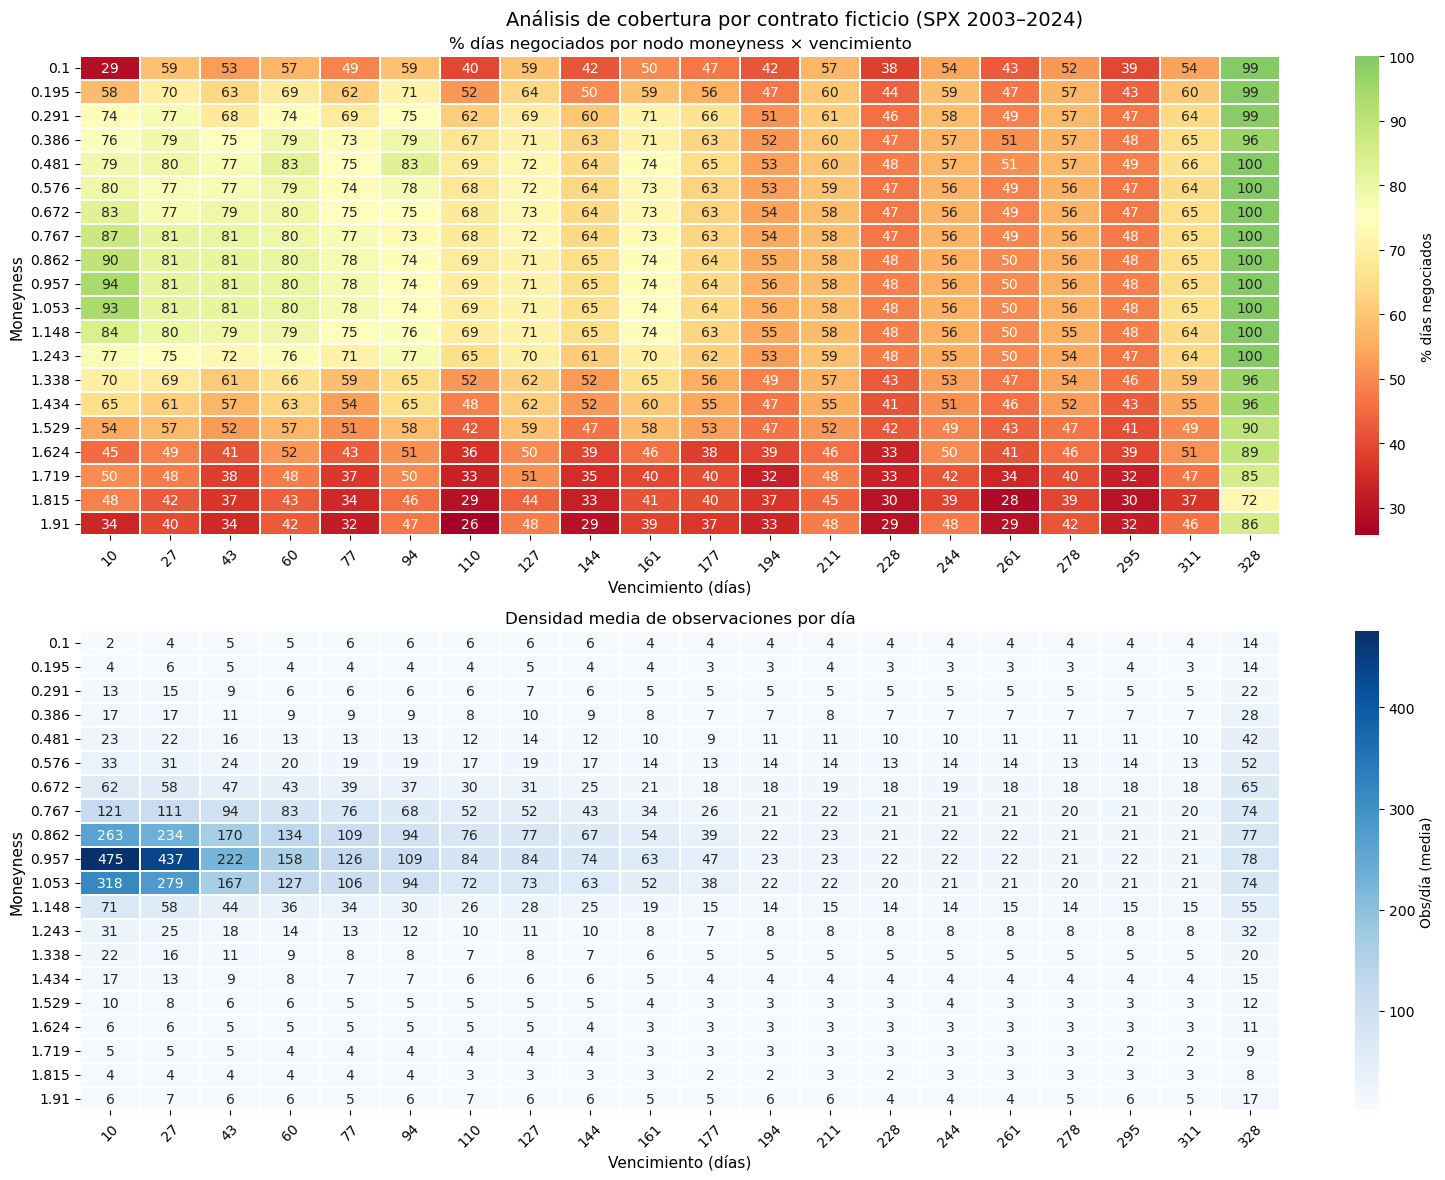

In [62]:
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Análisis de cobertura por contrato ficticio (SPX 2003–2024)', fontsize=14)
gs  = GridSpec(2, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, :])  # fila completa
ax2 = fig.add_subplot(gs[1, :])  # fila completa

# Filtrar contratos con pct_medio >= 50%
summary_50 = summary[summary['pct_medio']>=0].copy()
summary_50['d_target'] = summary_50['d_target'].round(0).astype(int)
summary_50['m_target'] = summary_50['m_target'].round(3)

# 1. Heatmap de pct_medio en grid moneyness x days
pivot = summary_50.pivot_table(
    index='m_target', columns='d_target', values='pct_medio'
)

sns.heatmap(pivot, ax=ax1, cmap='RdYlGn', center=75,
            annot=True, fmt='.0f', linewidths=0.3,
            cbar_kws={'label': '% días negociados'})
ax1.set_title('% días negociados por nodo moneyness × vencimiento', fontsize=12)
ax1.set_xlabel('Vencimiento (días)', fontsize=11)
ax1.set_ylabel('Moneyness', fontsize=11)
ax1.tick_params(axis='x', rotation=45)
ax1.tick_params(axis='y', rotation=0)
ax1.xaxis.set_tick_params(labelbottom=True)  

# 2. Heatmap de mean_obs_day
pivot_obs = summary_50.pivot_table(index='m_target', columns='d_target', values='mean_obs_day')

sns.heatmap(pivot_obs, ax=ax2, cmap='Blues',
            annot=True, fmt='.0f', linewidths=0.3,
            cbar_kws={'label': 'Obs/día (media)'})
ax2.set_title('Densidad media de observaciones por día', fontsize=12)
ax2.set_xlabel('Vencimiento (días)', fontsize=11)
ax2.set_ylabel('Moneyness', fontsize=11)
ax2.tick_params(axis='x', rotation=45)
ax2.tick_params(axis='y', rotation=0)
ax2.xaxis.set_tick_params(labelbottom=True)  


plt.tight_layout()
plt.show()

Asignamos estos contratos ficticios a dataframe completo para proceder al análisis de liquidez por volumen y OI:

In [63]:
# Añadir las columnas de nodo al dataframe original
filt_opt_df['m_target'] = target_moneyness[
    pd.cut(filt_opt_df['Moneyness'], bins=m_edges, labels=False, include_lowest=True).astype(int)
]

filt_opt_df['d_target'] = target_days[
    pd.cut(filt_opt_df['Days'], bins=d_edges, labels=False, include_lowest=True).astype(int)
]

filt_opt_df['m_target'] = filt_opt_df['m_target'].round(3)
filt_opt_df['d_target'] = filt_opt_df['d_target'].round(0).astype(int)

filt_opt_df['contract_ficticio'] = (
    'M=' + filt_opt_df['m_target'].astype(str) +
    '|T=' + filt_opt_df['d_target'].astype(str)
)

In [67]:
#ejemplo:
contratos_validos = summary[summary['pct_medio'] >= 50]['contract_ficticio'].tolist()
filt_opt_df_clean = filt_opt_df[filt_opt_df['contract_ficticio'].isin(contratos_validos)]

### Veamos ahora los estadísticos principales de las variables OI y Volumen:

#### Comparemos la relación entre contratos reales (OptionID) con el volumen y OI:

¿Cuales son los contratos más negociados tras controlar por volumen distinto a cero?

In [ ]:
# replicar análisis 

¿Cuales son los contratos negociados con volumen y OI distinto a cero?

¿Cuales son los contratos ficticios (agrupados) tras controlar por volumen distinto a cero?

In [ ]:
¿

¿Y aquellos con volumen y OI distinto positivos?



### Funciones:

In [ ]:
def interpolate_rates(
    curve_df: pd.DataFrame,
    expiry_days: pd.Series,
    currency: int,
    base: float = 365) -> pd.Series:
    """
    Interpolación de tasas de interés continuously compounded.

    Flujo:
        Se interpolan linealmente los log(DF) = -r·t/base, lo que equivale a
        interpolación log-lineal de factores de descuento. Se recuperan luego
        las tasas interpoladas a partir del log(DF) interpolado.

    Parameters
    ----------
    curve_df     : DataFrame con columnas [Currency, Date, Days, Rate]
    expiry_days  : Series con los días a interpolar
    currency     : Código de moneda (e.g. 272, 864, 1, ...)
    base         : Base de días para la convención day-count (default 365)

    Returns
    -------
    Series con los rates interpolados, mismo índice que expiry_days
    """
  
    curve = (
        curve_df[curve_df["Currency"] == currency]
        .sort_values("Days")
        .reset_index(drop=True)
    )
    days  = curve["Days"].values.astype(float)
    rates = curve["Rate"].values

 
    log_df = -rates * days / base

 
    t = expiry_days.values.astype(float)
    log_df_interp = np.interp(t, days, log_df)

   
    rates_interp = np.where(
        t > 0,
        -log_df_interp * base / t,
        rates[0] 
    )

    return pd.DataFrame(
        {"Days": expiry_days.values, "Rate": rates_interp},
        index=expiry_days.index,
    )


In [ ]:
def interpolate_rates_surface(
    curve_df: pd.DataFrame,
    vol_fecha: pd.DataFrame,
    fecha: pd.Timestamp,
    currency: int,
    base: float = 365.0,
) -> pd.Series:
    """
    Interpola r para todos los vencimientos de una fecha de la superficie.

    Parameters
    ----------
    curve_df  : DataFrame completo de zero curve [Currency, Date, Days, Rate]
    vol_fecha : DataFrame de opciones para una única fecha
    fecha     : Fecha de observación
    currency  : Código de divisa
    base      : Convención day-count (default 365)

    Returns
    -------
    pd.Series con r interpolado, mismo índice que vol_fecha
    """
    curva_fecha = curve_df[curve_df["Date"] == fecha]
    return interpolate_rates(curva_fecha, vol_fecha["Days"], currency, base)["Rate"]


### Pruebas:

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy import stats

# # prueba varias distribuciones
# for dist_name in ['norm', 'lognorm', 'gamma']:
#     dist = getattr(stats, dist_name)
#     params = dist.fit(opt_df_2['Strike'])
#     ks_stat, p_value = stats.kstest(opt_df_2['Strike'], dist_name, params)
#     print(f"{dist_name}: KS={ks_stat:.4f}, p={p_value:.4f}")



# # fig, ax = plt.subplots(figsize=(12, 5))

# # # Histograma normalizado (densidad)
# # opt_df_2['Strike'].plot.hist(bins=np.arange(0, 12500, 50), ax=ax, 
# #                               density=True, color='steelblue', 
# #                               alpha=0.4, edgecolor='white', label='Datos')

# # # Rango para las curvas teóricas
# # x = np.linspace(0, 8000, 1000)

# # # Ajustar y plotear cada distribución
# # colors = {'norm': 'tomato', 'lognorm': 'green', 'gamma': 'orange'}

# # for dist_name, color in colors.items():
# #     dist = getattr(stats, dist_name)
# #     params = dist.fit(opt_df_2['Strike'])
# #     ks_stat, p_value = stats.kstest(opt_df_2['Strike'], dist_name, params)
    
# #     pdf = dist.pdf(x, *params)
# #     ax.plot(x, pdf, color=color, linewidth=2, 
# #             label=f'{dist_name} (KS={ks_stat:.3f}, p={p_value:.3f})')

# # ax.set_xlim(0, 8000)
# # ax.set_xlabel('Strike', fontsize=12)
# # ax.set_ylabel('Densidad', fontsize=12)
# # ax.set_title('Ajuste de distribuciones teóricas (SPX 2003–2024)', fontsize=13)
# # ax.legend(fontsize=11)
# # plt.tight_layout()
# # plt.show()

In [ ]:
# import numpy as np
# import pandas as pd

# def cboe_select_vectorized(bids, asks, index):
#     """
#     Recorre strikes desde ATM hacia afuera y para al encontrar
#     dos consecutivos con Bid==0 o Ask==0. Devuelve índices válidos.
#     """
#     zero_count = 0
#     selected = []
#     invalid = (bids == 0) | (asks == 0)  # array booleano
    
#     for i, (is_zero, idx) in enumerate(zip(invalid, index)):
#         if is_zero:
#             zero_count += 1
#             if zero_count >= 2:
#                 break
#         else:
#             zero_count = 0
#             selected.append(idx)
#     return selected


# def cboe_strike_selection(group):
#     # K0: strike más cercano al forward
#     K0_idx = (group['Strike'] - group['forward_index'].iloc[0]).abs().idxmin()
#     K0     = group.loc[K0_idx, 'Strike']

#     # Separar y ordenar
#     puts_otm  = group[(group['CallPut'] == 'P') & (group['Strike'] < K0)].sort_values('Strike', ascending=False)
#     calls_otm = group[(group['CallPut'] == 'C') & (group['Strike'] > K0)].sort_values('Strike', ascending=True)
#     atm       = group[group['Strike'] == K0]

#     # Selección vectorizada
#     sel_puts  = cboe_select_vectorized(puts_otm['Bid'].values,  puts_otm['Ask'].values,  puts_otm.index)
#     sel_calls = cboe_select_vectorized(calls_otm['Bid'].values, calls_otm['Ask'].values, calls_otm.index)

#     valid_idx = sel_puts + sel_calls + atm.index.tolist()
#     return group.loc[valid_idx]


# # Aplicar
# result = (
#     opt_df_2
#     .groupby(['Date', 'Expiration'], group_keys=False)
#     .apply(cboe_strike_selection)
#     .reset_index(drop=True)
# )

# print(f"Filas originales:       {len(opt_df_2):,}")
# print(f"Filas tras filtro CBOE: {len(result):,}")
# print(f"Reducción:              {100*(1 - len(result)/len(opt_df_2)):.1f}%")